In [3]:
from pathlib import Path
import shutil
import kagglehub

# Returns the local cache path (downloads only if needed)
path = kagglehub.dataset_download("kundanbedmutha/student-performance-dataset")
source_dir = Path(path)

cwd = Path.cwd()
target_dir = cwd if cwd.name.lower() == "notebooks" else cwd / "notebooks"
target_dir.mkdir(parents=True, exist_ok=True)

for item in source_dir.iterdir():
    destination = target_dir / item.name

    if destination.exists():
        if destination.is_dir():
            shutil.rmtree(destination)
        else:
            destination.unlink()

    shutil.move(str(item), str(destination))

# Clean up empty source directory if everything was moved
if source_dir.exists() and not any(source_dir.iterdir()):
    source_dir.rmdir()

print(f"Dataset moved from: {source_dir}")
print(f"Dataset moved to:   {target_dir}")

Dataset moved from: C:\Users\ASUD Vivo\.cache\kagglehub\datasets\kundanbedmutha\student-performance-dataset\versions\1
Dataset moved to:   e:\Documents\AI\Student_Performance\notebooks


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kundanbedmutha/student-performance-dataset")

print("Path to dataset files:", path)

e:\Documents\AI\Student_Performance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 516k/516k [00:00<00:00, 902kB/s]

Extracting files...
Path to dataset files: C:\Users\ASUD Vivo\.cache\kagglehub\datasets\kundanbedmutha\student-performance-dataset\versions\1


In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ASUD Vivo\AppData\Local\Temp\ipykernel_26432\1837386673.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")


In [5]:
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [7]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [10]:
corr = df.select_dtypes(include=np.number).corr()

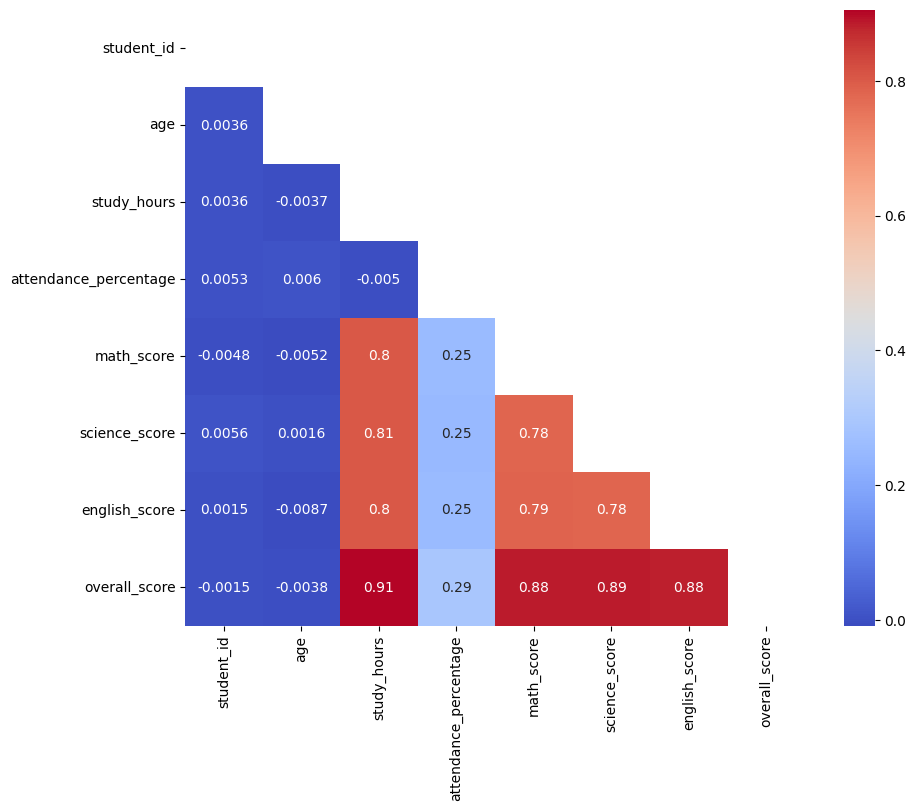

In [25]:
# plt.figure(figsize=(6, 10))
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

In [60]:
df.dtypes

student_id                 int64
age                        int64
gender                       str
school_type                  str
parent_education             str
study_hours              float64
attendance_percentage    float64
internet_access              str
travel_time                  str
extra_activities             str
study_method                 str
math_score               float64
science_score            float64
english_score            float64
overall_score            float64
final_grade                  str
dtype: object

# 📊 Data Preprocessing Notes

## 🔹 Categorical Features
These columns represent categories (no direct numerical meaning):

- gender            →  one hot encoding - drop first
- parent_education   → ordinal map()
- travel_time       →  ordinal map()
- study_method       → one hot encoding - drop first
- final_grade        → ordinal map()

---

## 🔹 Binary Features (Boolean Encoding)
Convert these columns to binary:

- internet_access → 1 = yes, 0 = no  
- extra_activities → 1 = yes, 0 = no 
-  school_type


---

## 🔹 Numerical Features
Keep these columns as they are (continuous values):

- scores (and other numeric columns like study_hours, attendance_percentage)

---

## 🧠 Notes / Decisions

- Categorical features will require encoding (One-Hot or Ordinal based on context)
- Binary features will be mapped directly to 0/1
- Numerical features will remain unchanged

<span style="background-color:yellow;  color:black; padding:6px;"> **Categorical Columns Selection :** </span>

In [71]:
categorical_cols = []

for col in df.columns:
    if (
        df[col].dtype == 'object' 
        or (df[col].nunique() < 10 and df[col].dtype not in ['float64', 'int64'])
    ):
        categorical_cols.append(col)

non_numerical_categories = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [df[col].nunique() for col in categorical_cols],
    "unique_values": [list(df[col].unique())[:5] for col in categorical_cols]
})

non_numerical_categories


,column,n_unique,unique_values
0,gender,3,"[male, female, other]"
1,school_type,2,"[public, private]"
2,parent_education,6,"[post graduate, graduate, high school, no form..."
3,internet_access,2,"[yes, no]"
4,travel_time,4,"[<15 min, >60 min, 15-30 min, 30-60 min]"
5,extra_activities,2,"[yes, no]"
6,study_method,6,"[notes, textbook, group study, coaching, mixed]"
7,final_grade,6,"[e, d, b, f, c]"


<span style="background-color:yellow;  color:black; padding:6px;"> **binary columns handing :** </span>

In [ ]:
df["internet_access"] = df["internet_access"].map({"yes": 1, "no": 0})
df["extra_activities"] = df["extra_activities"].map({"yes": 1, "no":0})
df["school_type"] = df["school_type"].map({"public" : 0, "private" : 1})

<span style="background-color:yellow;  color:black; padding:6px;"> **Categorical columns handing :** </span>

In [ ]:
# One Hot Encoding :)
df = pd.get_dummies(df, columns=['gender', 'study_method'], drop_first=True)

# Mapping

df["parent_education"] = df["parent_education"].map({"no formal": 0, "high school": 1 , "diploma" : 2, "graduate" : 3, "post graduate": 4 , "phd": 5})
df["travel_time"] = df["travel_time"].map({"<15 min": 0, ">60 min" : 3, "15-30 min" : 1, "30-60 min" : 2})
df["final_grade"] = df["final_grade"].map({'f': 0, 'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})



In [101]:
df

,student_id,age,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,...,english_score,overall_score,final_grade,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,1,14,0,4,3.1,84.3,1,0,1,42.7,...,57.0,53.1,1,True,False,False,False,True,False,False
1,2,18,0,3,3.7,87.8,1,3,0,57.6,...,64.8,61.3,2,False,False,False,False,False,False,True
2,3,17,1,4,7.9,65.5,0,0,0,84.8,...,79.2,89.6,4,False,False,False,False,True,False,False
3,4,16,0,1,1.1,58.1,0,1,0,44.4,...,54.7,41.6,1,False,True,False,False,True,False,False
4,5,16,0,1,1.3,61.0,1,2,1,8.9,...,30.0,25.4,0,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,0,5,1.8,55.2,1,1,0,55.8,...,46.7,46.1,1,False,False,False,True,False,False,False
24996,1102,16,1,2,2.7,97.1,1,0,0,64.8,...,52.3,56.5,2,False,False,False,False,False,False,False
24997,4422,19,1,4,1.0,63.0,1,0,0,50.5,...,36.1,36.7,0,False,True,True,False,False,False,False
24998,7858,14,1,2,1.0,69.4,1,1,1,13.0,...,7.3,34.1,0,True,False,True,False,False,False,False


<span style="background-color:yellow;  color:black; padding:6px;"> **Explore Distribution of numerical columns :** </span>

In [113]:
numerical_columns = ['study_hours',
       'attendance_percentage',
       'math_score', 'science_score', 'english_score',
       'overall_score' 
       ]

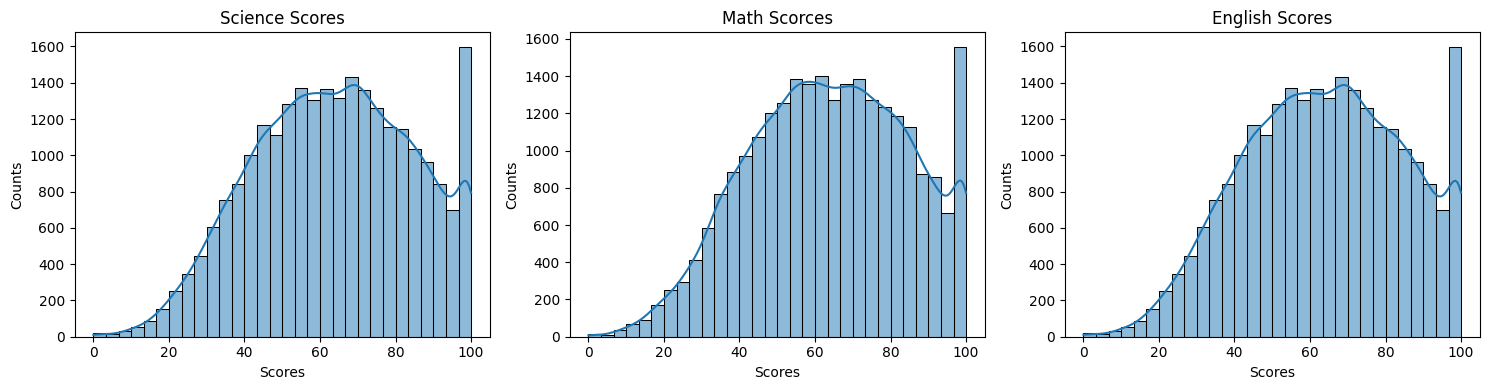

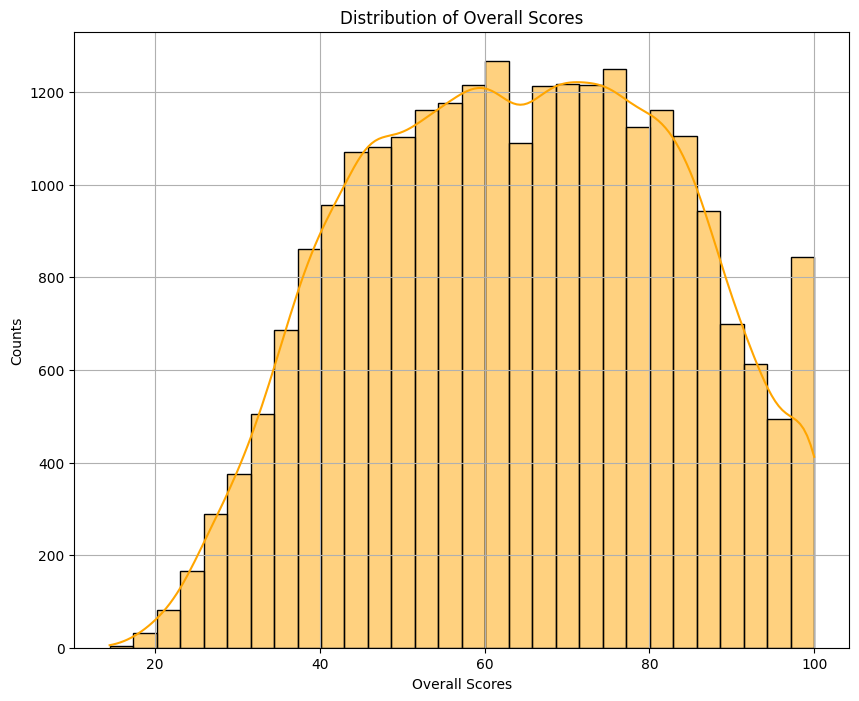

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df['science_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1
sns.histplot(df["science_score"], bins=30, kde = True, ax =  axes[0])
axes[0].set_title("Science Scores")
axes[0].set_xlabel("Scores")
axes[0].set_ylabel("Counts")

#2
sns.histplot(df["math_score"], bins=30, kde = True, ax =  axes[1])
axes[1].set_title("Math Scorces")
axes[1].set_xlabel("Scores")
axes[1].set_ylabel("Counts")

# 3
sns.histplot(df["science_score"], bins=30, kde = True, ax =  axes[2])
axes[2].set_title("English Scores")
axes[2].set_xlabel("Scores")
axes[2].set_ylabel("Counts")

plt.tight_layout()
plt.show()

plt.figure(figsize = (10, 8))
sns.histplot(df['overall_score'], color = "orange", edgecolor= "black", bins = 30, kde = True)
plt.xlabel("Overall Scores")
plt.ylabel("Counts")
plt.title("Distribution of Overall Scores")
plt.grid(True)

Index(['student_id', 'age', 'school_type', 'parent_education', 'study_hours',
       'attendance_percentage', 'internet_access', 'travel_time',
       'extra_activities', 'math_score', 'science_score', 'english_score',
       'overall_score', 'final_grade', 'gender_male', 'gender_other',
       'study_method_group study', 'study_method_mixed', 'study_method_notes',
       'study_method_online videos', 'study_method_textbook'],
      dtype='str')

In [ ]:
# study hours && overall score
# attendance && overall score
# study hours && attendance 

# external activities && overall score 
# school type overall score 

# full compersion between public and private schools 
# includes -> external activities rates, overall score, attendance 

# full compersion amoung students in different parent education level 
# includes -> attendance && school type && study hours && overall score 

# full compresion amoung different study methods 
# includes -> overall scores && most highly subject && study hours 



In [ ]:
# use linear algebra model with this data 
# using sklearn library 